In [1]:
import pandas as pd
import numpy as np
import os


os.chdir('/Users/dannyhogan/Desktop/ST-498/Code')
from DH_Branch_Fitting import run_sarima_pipeline, fit_all_transformations, forecast_best_model

In [2]:
os.chdir('/Users/dannyhogan/Desktop/ST-498/Code')
from SARIMA_Forecasting import forecast_all
from Exog_Variable_Selection import (
    get_residuals, scan_exog_candidates, granger_test,
    compute_vif, plot_all_ccfs
)

from SARIMAX_Fitting import run_sarimax_pipeline


ImportError: cannot import name 'granger_test' from 'Exog_Variable_Selection' (/Users/dannyhogan/Desktop/ST-498/Code/Exog_Variable_Selection.py)

In [ ]:
os.chdir('/Users/dannyhogan/Desktop/ST-498')


In [ ]:
os.chdir('/Users/dannyhogan/Desktop/ST-498')
df_US = pd.read_csv("Data/MacroVariablesUS.csv", index_col=0)



x = df_US.drop(columns=['US_Credit'])
y = df_US['US_Credit']


In [ ]:
results, comparisons = run_sarima_pipeline(df_US, m=4, n_periods=8)
all_forecasts = forecast_all(
    df=df_US,
    results=results,
    n_periods=20,       # 5 years × 4 quarters
    freq="QS",
    plot=True,
    save_dir="./forecast_plots",)


In [6]:
# ── Crisis Dummy ──────────────────────────────────────────────
df_US['crisis'] = 0
df_US.loc['2001-01-01':'2001-10-01', 'crisis'] = 1   # Dot-com
df_US.loc['2007-10-01':'2009-04-01', 'crisis'] = 1   # GFC
df_US.loc['2020-01-01':'2020-04-01', 'crisis'] = 1   # COVID
print(f"Crisis quarters: {df_US['crisis'].sum()} / {len(df_US)}")

# ── Stationary candidates ────────────────────────────────────
candidates = {
    # pct_change for levels
    'house_prices_pct':  df_US['US_house_prices'].pct_change().dropna(),
    'gdp_growth':        df_US['US_rGDP'].pct_change().dropna(),
    'oil_pct_chg':       df_US['US_OilPrice'].pct_change().dropna(),
    'sp500_return':      df_US['US_SP500_Open'].pct_change().dropna(),
    'exchange_rate_pct': df_US['US_ExchangeRate'].pct_change().dropna(),
    # diff for rates
    'cpi_diff':          df_US['US_cpi'].diff().dropna(),
    'unemployment_diff': df_US['US_unemployment'].diff().dropna(),
    'bond_yield_diff':   df_US['US_BondYield'].diff().dropna(),
    'credit_diff':       df_US['US_Credit'].diff().dropna(),
    # dummy
    'crisis':            df_US['crisis'].astype(float),
}

Crisis quarters: 13 / 129


In [8]:


# Map each target to its own derivative (to exclude from candidates)
skip_map = {
    'US_house_prices': 'house_prices_pct',
    'US_cpi':          'cpi_diff',
    'US_unemployment': 'unemployment_diff',
    'US_ExchangeRate': 'exchange_rate_pct',
    'US_OilPrice':     'oil_pct_chg',
    'US_BondYield':    'bond_yield_diff',
    'US_rGDP':         'gdp_growth',
    'US_Credit':       'credit_diff',
    'US_SP500_Open':   'sp500_return',
}

target_cols = [c for c in df_US.columns if c != 'crisis']
selection_results = {}

for target in target_cols:
    if target not in results:
        continue

    print(f"\n{'='*70}")
    print(f"  {target}")
    print(f"{'='*70}")

    # A. Residuals — align to datetime index
    resid = get_residuals(results[target])
    series = df_US[target].dropna()
    resid.index = series.index[-len(resid):]

    # B. Exclude own derivative
    cands = {k: v for k, v in candidates.items() if k != skip_map.get(target)}

    # C. CCF scan
    ccf_summary = scan_exog_candidates(resid, cands, max_lags=8)
    print(ccf_summary.to_string(index=False))

    # D. Granger on significant CCF vars
    sig_vars = ccf_summary[ccf_summary['significant']]['variable'].tolist()
    shortlist = []

    for var_name in sig_vars:
        gt = granger_test(resid, cands[var_name], max_lag=4)
        any_sig = gt['significant'].any()
        best = gt.loc[gt['p_value'].idxmin()]
        tag = '✓' if any_sig else '✗'
        print(f"  Granger: {var_name:25s} lag={int(best['lag'])} p={best['p_value']:.4f} {tag}")
        if any_sig:
            shortlist.append(var_name)

    # Keep crisis if it passed CCF even if Granger was marginal
    if 'crisis' in sig_vars and 'crisis' not in shortlist:
        shortlist.append('crisis')

    # E. VIF
    if len(shortlist) >= 2:
        vif_df = pd.DataFrame({k: cands[k] for k in shortlist}).dropna()
        print(f"\n  VIF:")
        print(compute_vif(vif_df).to_string(index=False))

    print(f"\n  → Shortlist: {shortlist}")
    selection_results[target] = {
        'ccf_summary': ccf_summary,
        'shortlist':   shortlist,
    }


  US_house_prices
         variable  best_lag  best_ccf  abs_ccf  significant direction
      credit_diff         7   -0.2619   0.2619         True  negative
         cpi_diff         7    0.2225   0.2225         True  positive
exchange_rate_pct         7    0.1609   0.1609        False  positive
unemployment_diff         1    0.1557   0.1557        False  positive
      oil_pct_chg         1    0.1531   0.1531        False  positive
  bond_yield_diff         8    0.1514   0.1514        False  positive
     sp500_return         8    0.1458   0.1458        False  positive
           crisis         7   -0.1364   0.1364        False  negative
       gdp_growth         2   -0.1345   0.1345        False  negative
  Granger: credit_diff               lag=1 p=0.1316 ✗
  Granger: cpi_diff                  lag=1 p=0.7039 ✗

  → Shortlist: []

  US_cpi
         variable  best_lag  best_ccf  abs_ccf  significant direction
      credit_diff         5   -0.3604   0.3604         True  negative
    

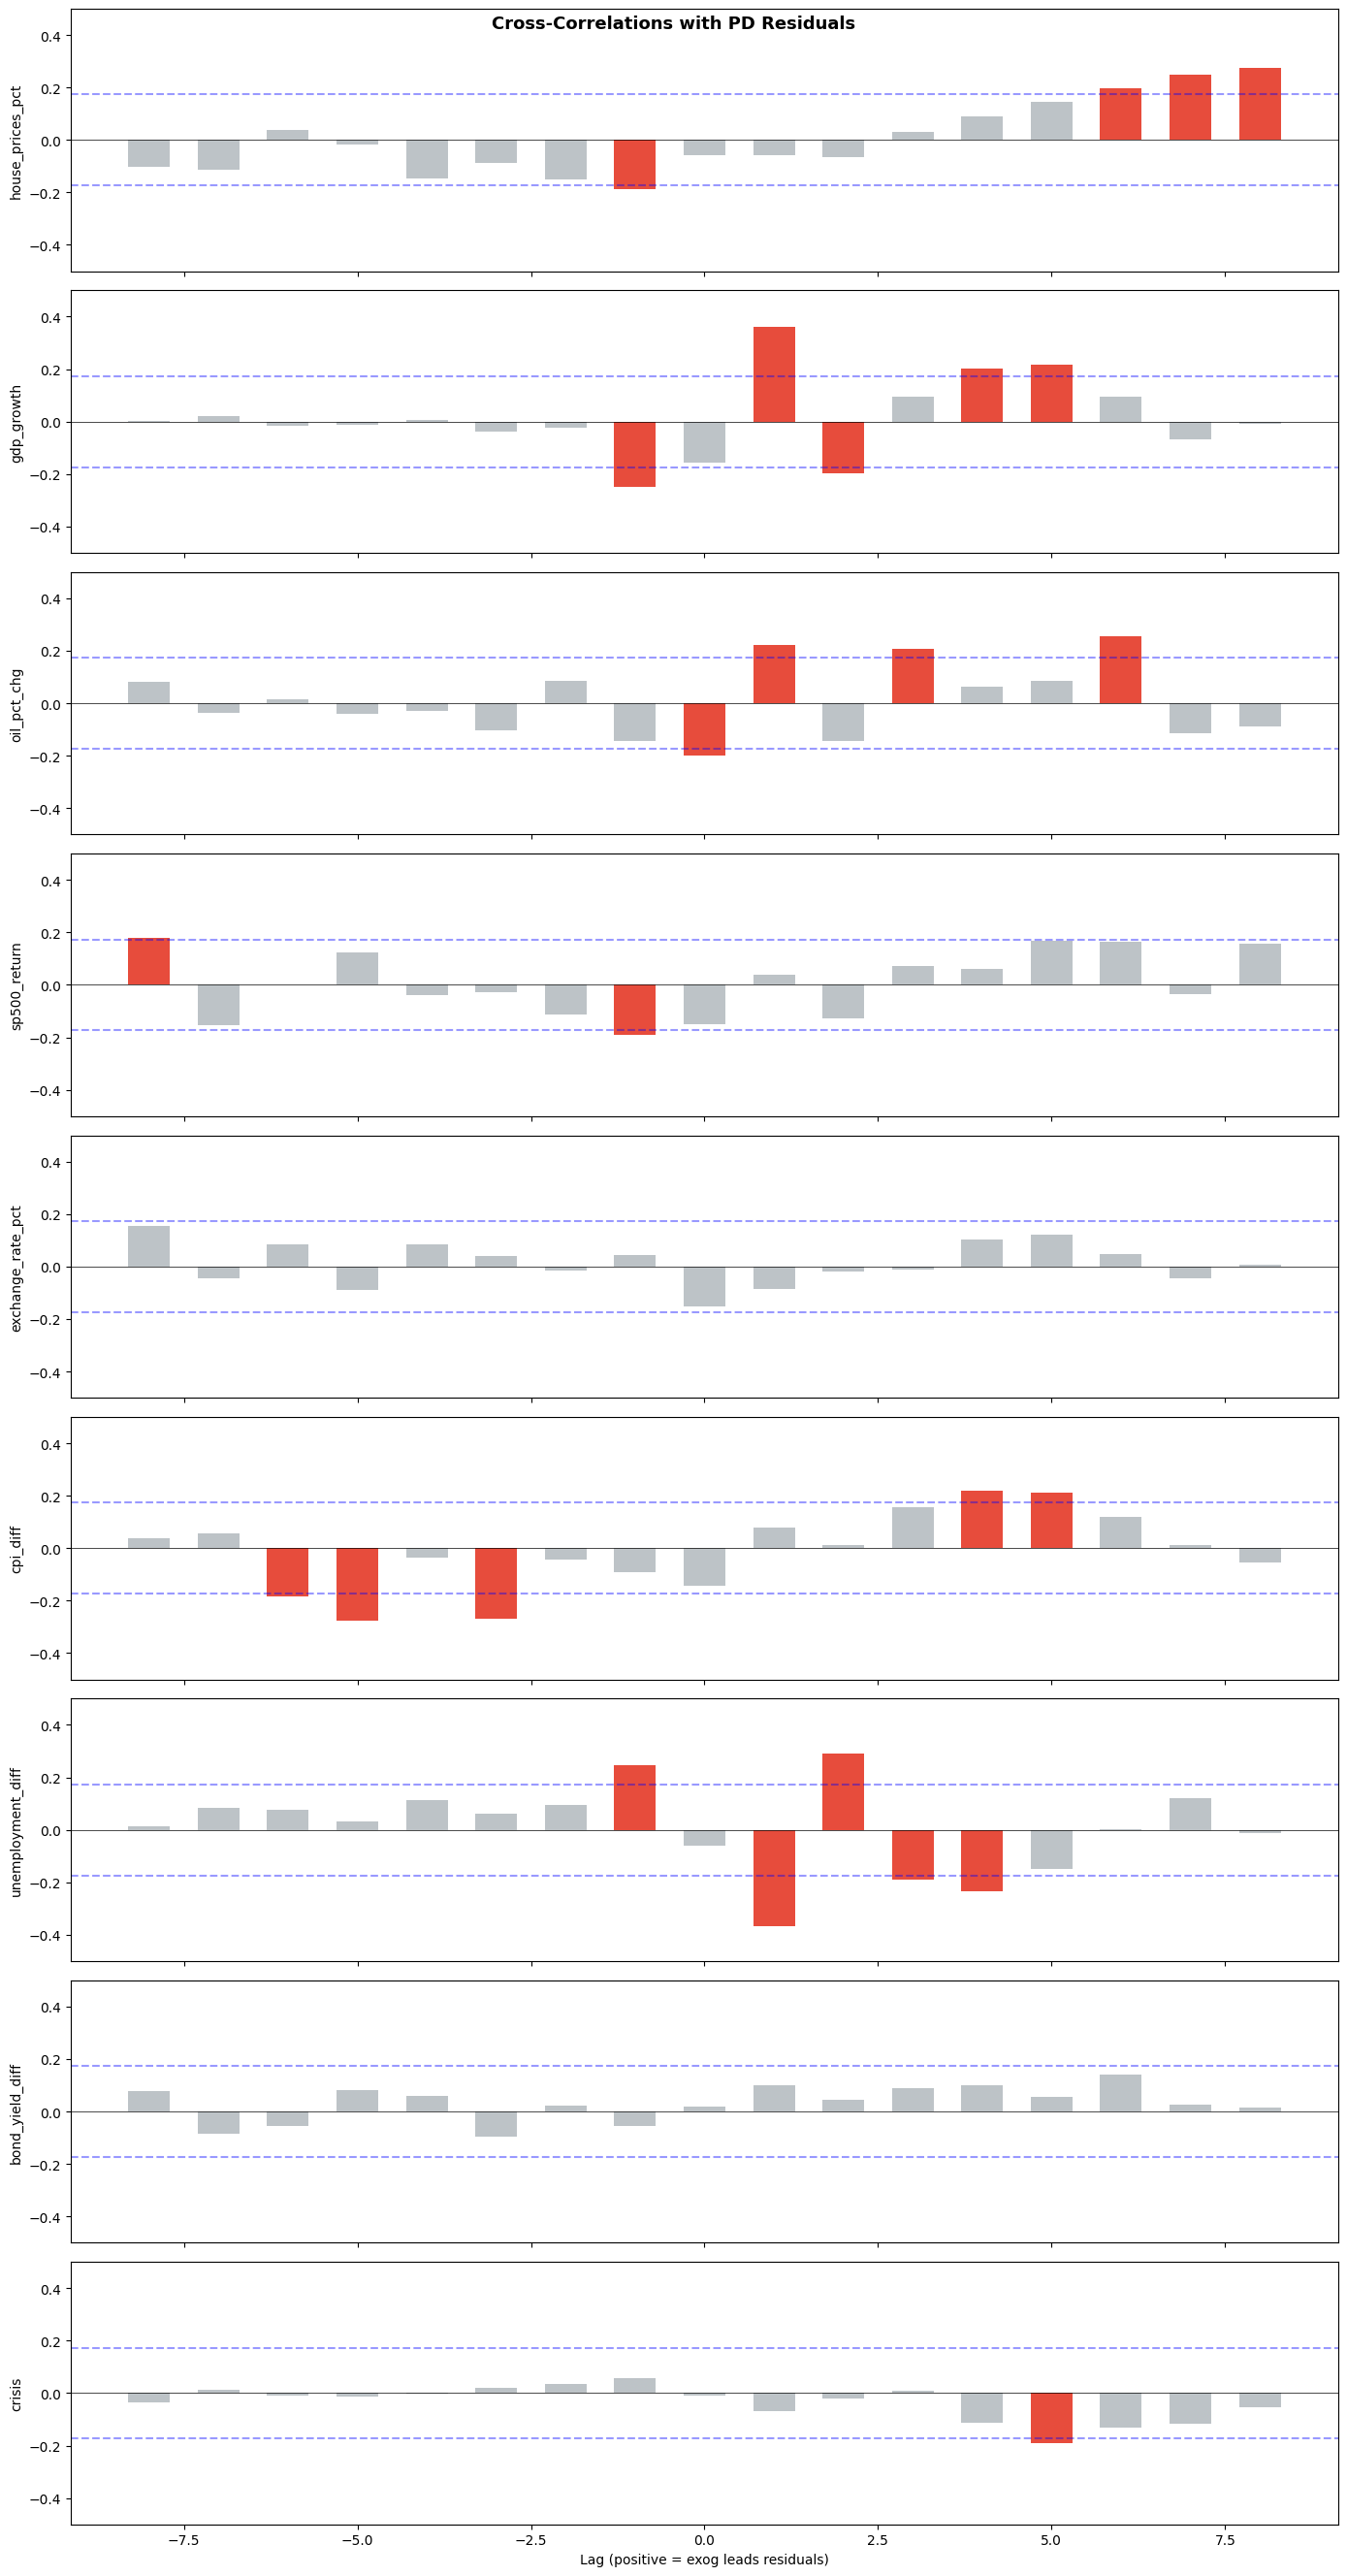

In [9]:
# Pick a target to inspect visually
target = 'US_Credit'  # ← change as needed

resid = get_residuals(results[target])
series = df_US[target].dropna()
resid.index = series.index[-len(resid):]
cands = {k: v for k, v in candidates.items() if k != skip_map.get(target)}

plot_all_ccfs(resid, cands, max_lags=8)

In [10]:
print(f"\n{'='*70}")
print(f"  EXOG VARIABLE RECOMMENDATIONS")
print(f"{'='*70}")
for target, sel in selection_results.items():
    order_str = f"{results[target]['order']}x{results[target]['seasonal_order']}"
    exog = ', '.join(sel['shortlist']) or '— univariate sufficient'
    print(f"  {target:<22s} {order_str:<28s} {exog}")


  EXOG VARIABLE RECOMMENDATIONS
  US_house_prices        (1, 1, 0)x(0, 0, 0, 4)       — univariate sufficient
  US_cpi                 (1, 0, 1)x(0, 0, 1, 4)       house_prices_pct, crisis
  US_unemployment        (2, 0, 0)x(0, 0, 0, 4)       crisis, house_prices_pct
  US_ExchangeRate        (1, 0, 0)x(0, 0, 1, 4)       oil_pct_chg
  US_OilPrice            (0, 1, 1)x(0, 0, 0, 4)       cpi_diff, house_prices_pct, credit_diff
  US_BondYield           (0, 1, 0)x(0, 0, 0, 4)       house_prices_pct, oil_pct_chg, sp500_return, gdp_growth, unemployment_diff, crisis
  US_rGDP                (0, 1, 1)x(0, 0, 0, 4)       crisis, unemployment_diff, house_prices_pct, credit_diff
  US_Credit              (3, 1, 0)x(2, 0, 1, 4)       unemployment_diff, gdp_growth, oil_pct_chg, crisis
  US_SP500_Open          (0, 1, 0)x(0, 0, 0, 4)       crisis, exchange_rate_pct, credit_diff



  US_house_prices
  No exog variables selected → univariate SARIMA only
  Saved → ./sarimax_plots/US_house_prices_sarima.png


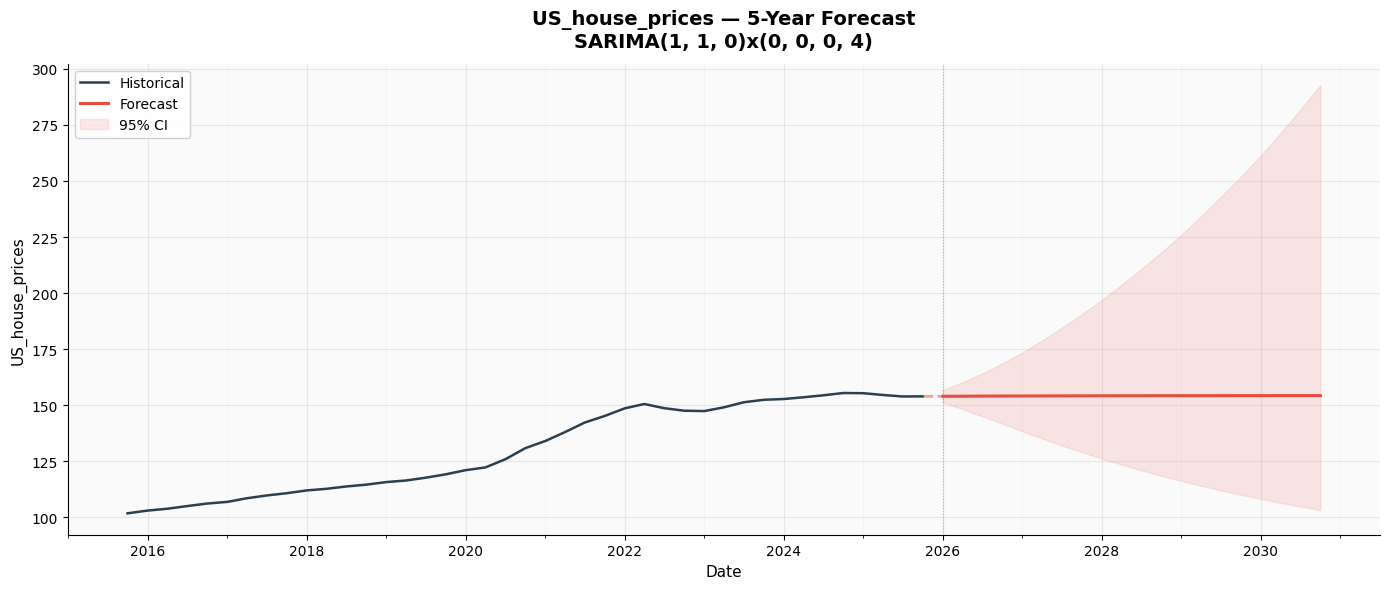


  US_cpi

  Fitting SARIMAX(1, 0, 1)x(0, 0, 1, 4)  transform=[yeo-johnson]  exog=['house_prices_pct', 'crisis']
  Observations: 126  |  Exog vars: 2
  AIC=157.40  BIC=177.25  Residual σ=0.4231

  SARIMA  AIC = 155.09
  SARIMAX AIC = 157.40
  Δ AIC = -2.31  →  SARIMA wins

            forecast     lower     upper
2025-10-01  2.902485  1.653077  4.286008
2026-01-01  2.717592  0.753497  5.066519
2026-04-01  2.919049  0.492960  5.933572
2026-07-01  2.663541  0.030439  6.093789
2026-10-01  2.515109 -0.093645  5.955283
2027-01-01  2.507763 -0.098923  5.946953
2027-04-01  2.500953 -0.103788  5.939182
2027-07-01  2.494638 -0.108274  5.931936
  Saved → ./sarimax_plots/US_cpi_sarimax.png


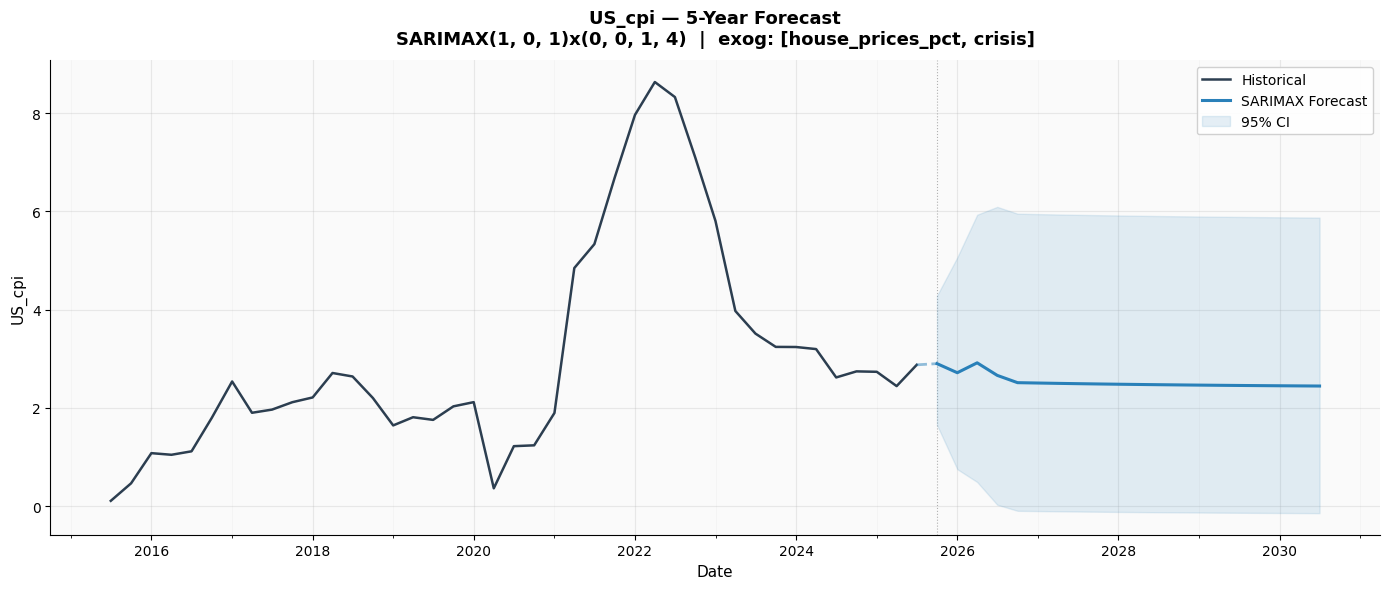


  US_unemployment

  Fitting SARIMAX(2, 0, 0)x(0, 0, 0, 4)  transform=[boxcox]  exog=['crisis', 'house_prices_pct']
  Observations: 127  |  Exog vars: 2
  AIC=-757.33  BIC=-740.26  Residual σ=0.0117

  SARIMA  AIC = -763.27
  SARIMAX AIC = -757.33
  Δ AIC = -5.94  →  SARIMA wins

            forecast     lower      upper
2026-01-01  4.470225  3.888088   5.299048
2026-04-01  4.474266  3.645291   5.913162
2026-07-01  4.475281  3.481077   6.499387
2026-10-01  4.475806  3.357103   7.096575
2027-01-01  4.476251  3.257179   7.729470
2027-04-01  4.476683  3.173266   8.418598
2027-07-01  4.477113  3.100833   9.185179
2027-10-01  4.477542  3.037070  10.054516
  Saved → ./sarimax_plots/US_unemployment_sarimax.png


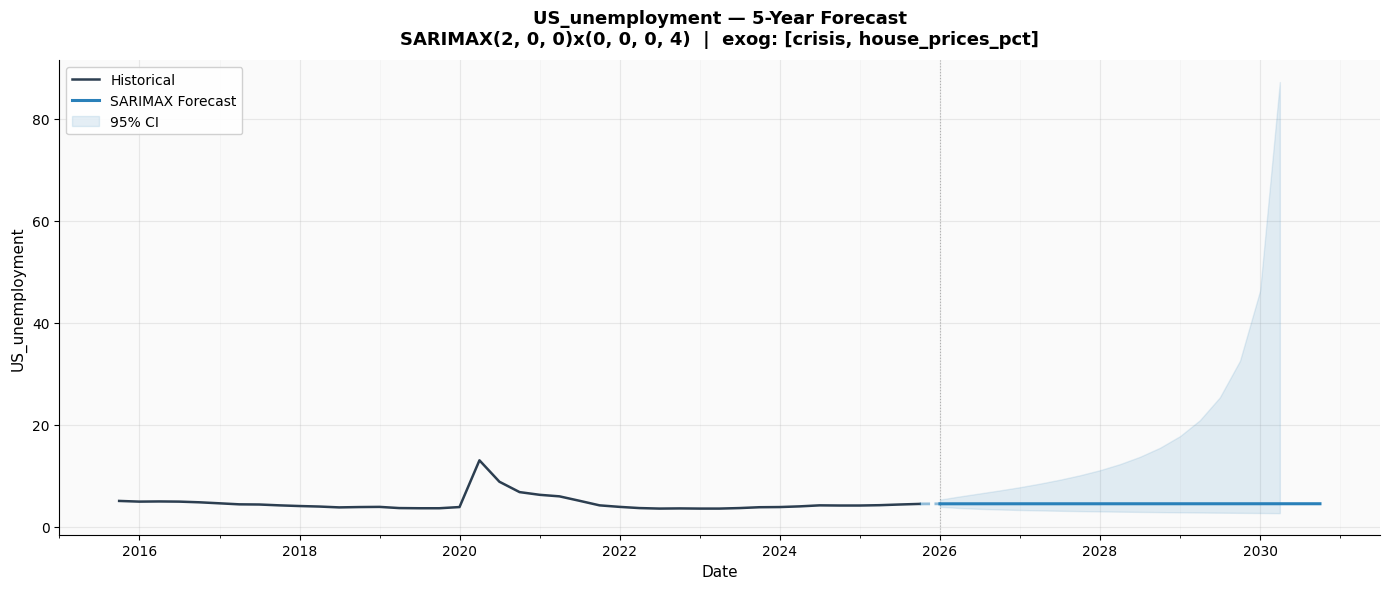


  US_ExchangeRate

  Fitting SARIMAX(1, 0, 0)x(0, 0, 1, 4)  transform=[log]  exog=['oil_pct_chg']
  Observations: 109  |  Exog vars: 1
  AIC=-347.40  BIC=-333.95  Residual σ=0.0468

  SARIMA  AIC = -349.40
  SARIMAX AIC = -347.40
  Δ AIC = -2.00  →  SARIMA wins

            forecast     lower     upper
2026-04-01  1.165979  1.064368  1.277289
2026-07-01  1.151172  1.015556  1.304899
2026-10-01  1.152461  0.992615  1.338047
2027-01-01  1.155292  0.976842  1.366341
2027-04-01  1.156106  0.968188  1.380497
2027-07-01  1.156874  0.960989  1.392687
2027-10-01  1.157599  0.954938  1.403270
2028-01-01  1.158284  0.949812  1.412514
  Saved → ./sarimax_plots/US_ExchangeRate_sarimax.png


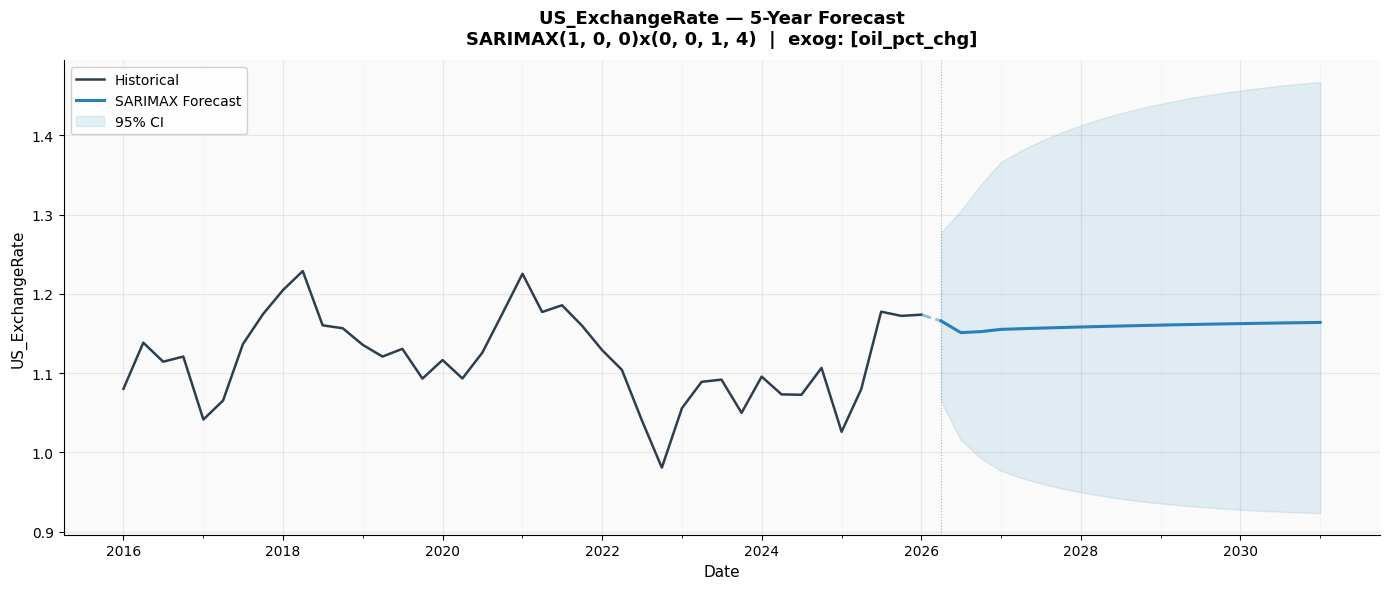


  US_OilPrice

  Fitting SARIMAX(0, 1, 1)x(0, 0, 0, 4)  transform=[log]  exog=['cpi_diff', 'house_prices_pct', 'credit_diff']
  Observations: 126  |  Exog vars: 3
  AIC=-40.91  BIC=-23.94  Residual σ=0.3142

  SARIMA  AIC = -41.10
  SARIMAX AIC = -40.91
  Δ AIC = -0.20  →  SARIMA wins

             forecast      lower       upper
2026-04-01  66.313905  45.183395   97.326330
2026-07-01  67.051344  41.690179  107.840332
2026-10-01  67.796983  39.047552  117.713677
2027-01-01  68.550915  36.917680  127.289360
2027-04-01  69.313230  35.135261  136.737958
2027-07-01  70.084022  33.605517  146.159637
2027-10-01  70.863386  32.268502  155.619851
2028-01-01  71.651417  31.083657  165.164788
  Saved → ./sarimax_plots/US_OilPrice_sarimax.png


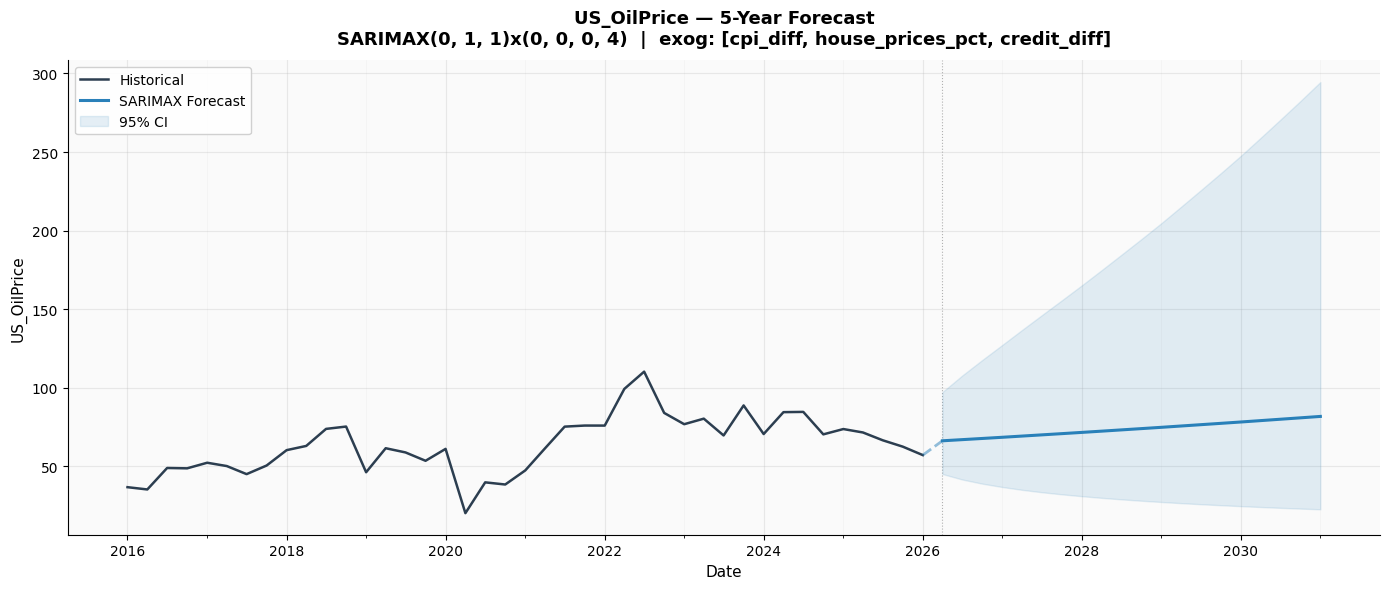


  US_BondYield

  Fitting SARIMAX(0, 1, 0)x(0, 0, 0, 4)  transform=[log]  exog=['house_prices_pct', 'oil_pct_chg', 'sp500_return', 'gdp_growth', 'unemployment_diff', 'crisis']
  Observations: 127  |  Exog vars: 6
  AIC=-107.66  BIC=-84.97  Residual σ=0.2317

  SARIMA  AIC = -96.04
  SARIMAX AIC = -107.66
  Δ AIC = 11.62  →  SARIMAX wins

            forecast     lower     upper
2026-04-01  3.984357  2.980400  5.326500
2026-07-01  3.966075  2.630581  5.979572
2026-10-01  3.947876  2.387702  6.527499
2027-01-01  3.929761  2.198866  7.023175
2027-04-01  3.911729  2.043794  7.486872
2027-07-01  3.893780  1.912189  7.928883
2027-10-01  3.875913  1.797993  8.355261
2028-01-01  3.858128  1.697298  8.769909
  Saved → ./sarimax_plots/US_BondYield_sarimax.png


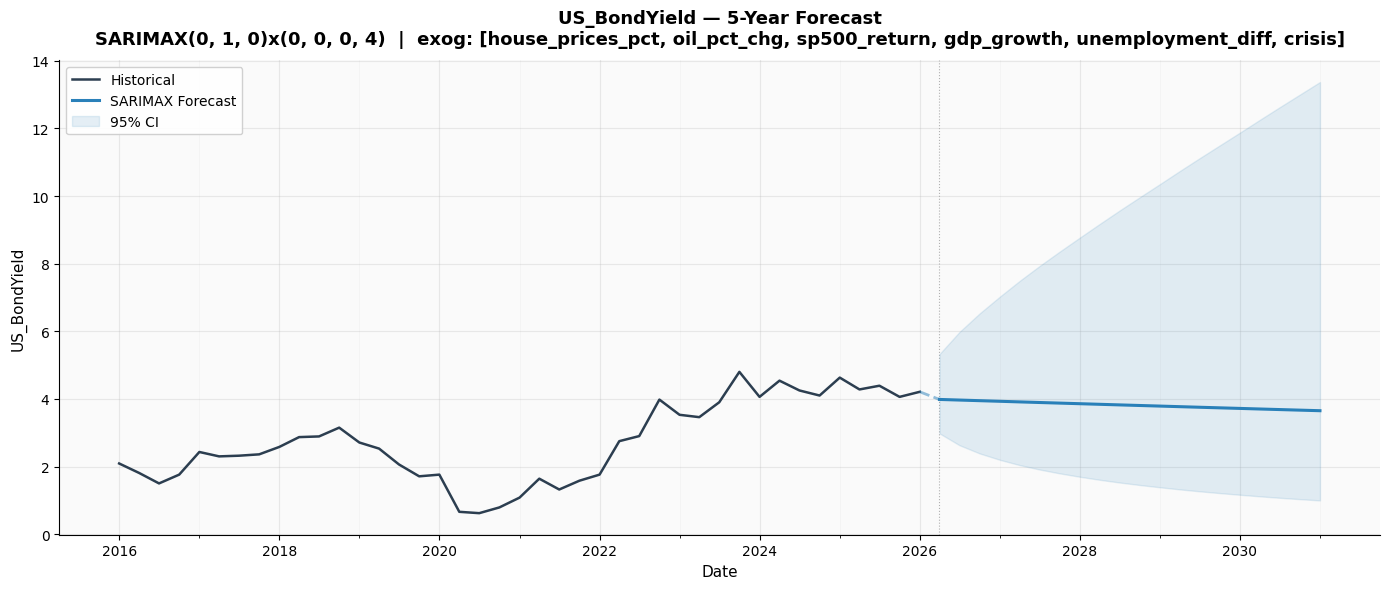


  US_rGDP

  Fitting SARIMAX(0, 1, 1)x(0, 0, 0, 4)  transform=[log]  exog=['crisis', 'unemployment_diff', 'house_prices_pct', 'credit_diff']
  Observations: 127  |  Exog vars: 4
  AIC=-904.94  BIC=-885.09  Residual σ=0.8258

  SARIMA  AIC = -770.49
  SARIMAX AIC = -904.94
  Δ AIC = 134.45  →  SARIMAX wins

                forecast         lower         upper
2026-01-01  24237.936967  23940.336749  24539.236627
2026-04-01  24387.901452  23892.294743  24893.788714
2026-07-01  24538.793795  23902.409760  25192.121085
2026-10-01  24690.619735  23937.598341  25467.329438
2027-01-01  24843.385050  23987.801492  25729.485087
2027-04-01  24997.095552  24048.362183  25983.257457
2027-07-01  25151.757088  24116.677516  26231.261923
2027-10-01  25307.375543  24191.121654  26475.136873
  Saved → ./sarimax_plots/US_rGDP_sarimax.png


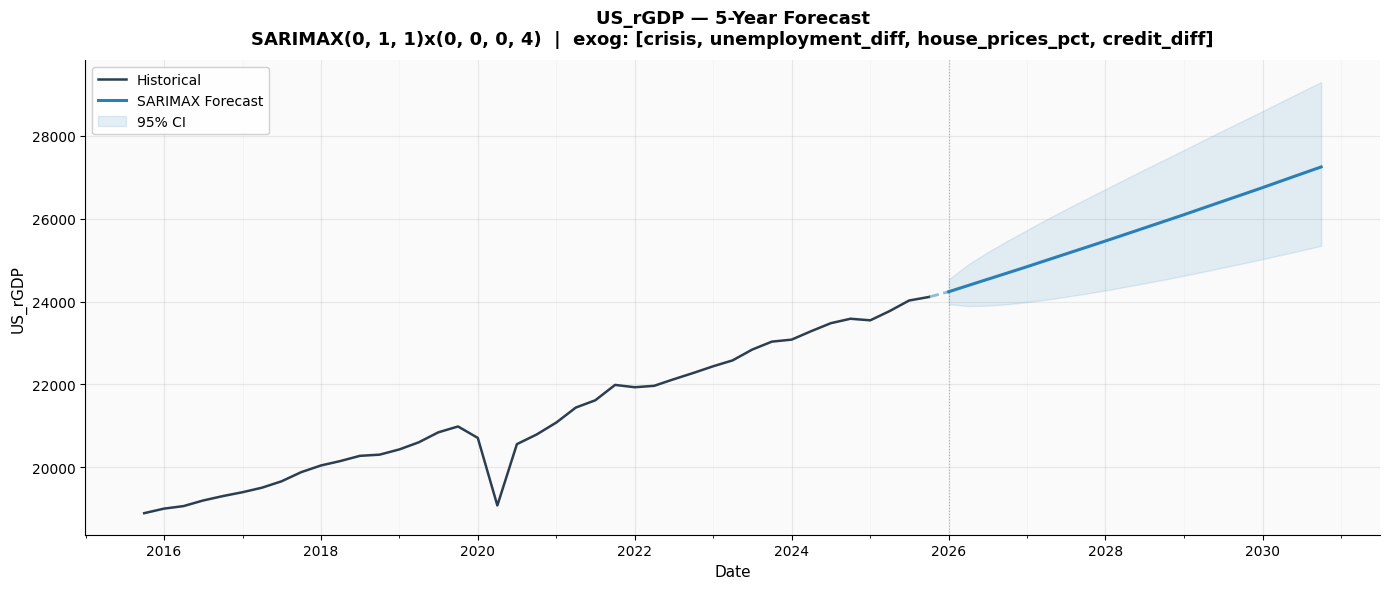


  US_Credit

  Fitting SARIMAX(3, 1, 0)x(2, 0, 1, 4)  transform=[log]  exog=['unemployment_diff', 'gdp_growth', 'oil_pct_chg', 'crisis']
  Observations: 127  |  Exog vars: 4
  AIC=-428.75  BIC=-394.72  Residual σ=0.1140

  SARIMA  AIC = -416.00
  SARIMAX AIC = -428.75
  Δ AIC = 12.76  →  SARIMAX wins

            forecast     lower     upper
2026-01-01  2.931841  2.712381  3.169057
2026-04-01  2.873095  2.501047  3.300489
2026-07-01  2.869584  2.363805  3.483584
2026-10-01  2.898655  2.248313  3.737114
2027-01-01  2.898500  2.123924  3.955557
2027-04-01  2.872117  1.992783  4.139466
2027-07-01  2.888965  1.899651  4.393500
2027-10-01  2.917418  1.820955  4.674102
  Saved → ./sarimax_plots/US_Credit_sarimax.png


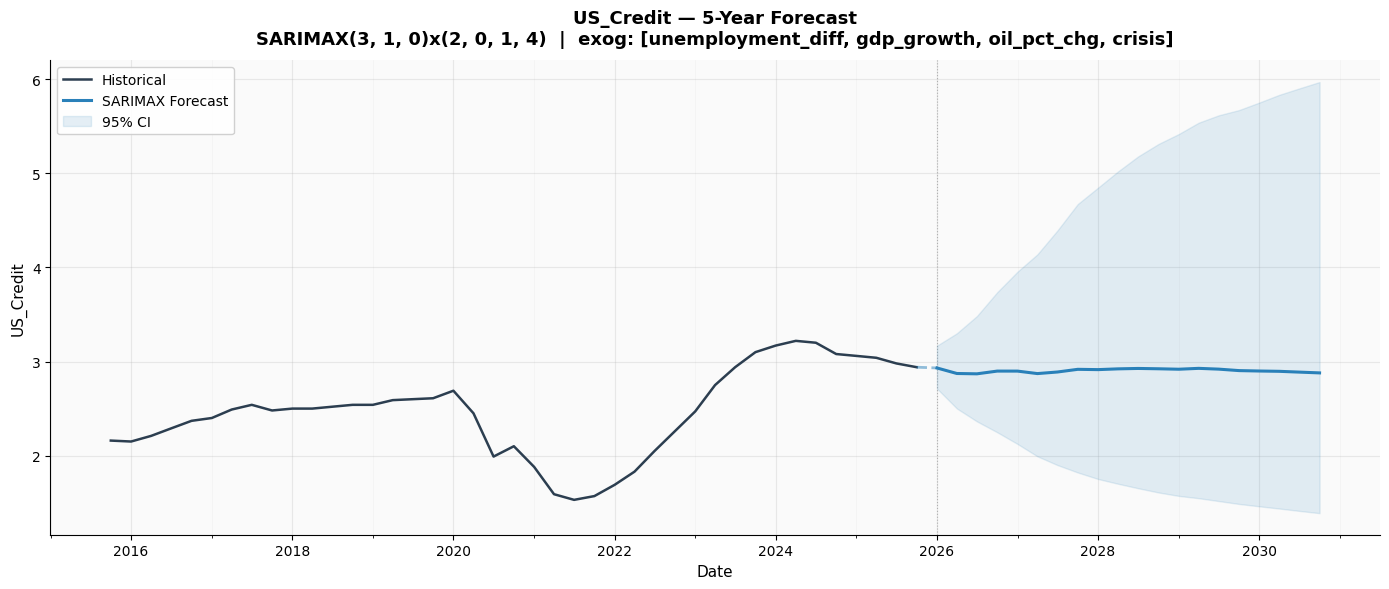


  US_SP500_Open

  Fitting SARIMAX(0, 1, 0)x(0, 0, 0, 4)  transform=[boxcox]  exog=['crisis', 'exchange_rate_pct', 'credit_diff']
  Observations: 107  |  Exog vars: 3
  AIC=-1265.35  BIC=-1252.04  Residual σ=0.1407

  SARIMA  AIC = -651.48
  SARIMAX AIC = -1265.35
  Δ AIC = 613.87  →  SARIMAX wins

               forecast        lower         upper
2026-04-01  6903.694430  4556.410299  1.235516e+04
2026-07-01  7108.285918  4029.849108  1.816550e+04
2026-10-01  7323.285940  3707.687045  2.714336e+04
2027-01-01  7549.454405  3478.173813  4.336434e+04
2027-04-01  7787.624245  3301.930850  7.973193e+04
2027-07-01  8038.710192  3160.275802  2.054216e+05
2027-10-01  8303.718830  3042.840629  3.316830e+06
2028-01-01  8583.760143  2943.270444           NaN
  Saved → ./sarimax_plots/US_SP500_Open_sarimax.png


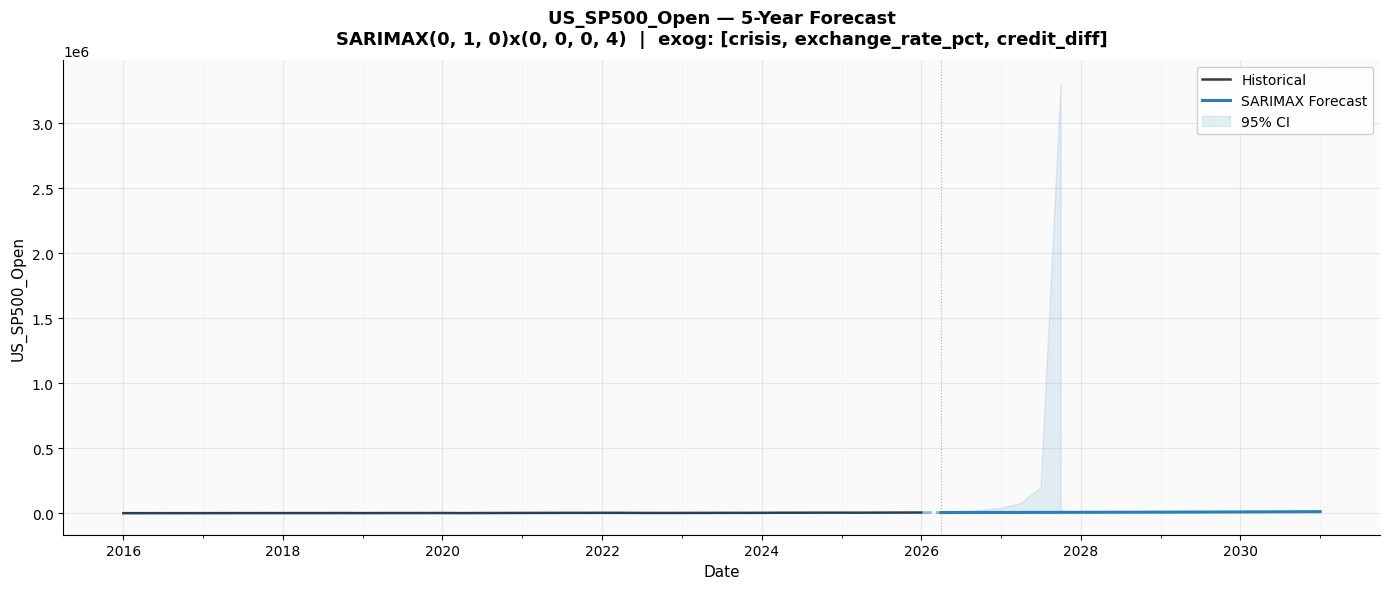



  SARIMAX PIPELINE SUMMARY
  Target                 Type              AIC Exog Vars
  ────────────────────── ────────── ────────── ───────────────────────────────────
  US_house_prices        SARIMA       -1994.01 —
  US_cpi                 SARIMAX        157.40 house_prices_pct, crisis
  US_unemployment        SARIMAX       -757.33 crisis, house_prices_pct
  US_ExchangeRate        SARIMAX       -347.40 oil_pct_chg
  US_OilPrice            SARIMAX        -40.91 cpi_diff, house_prices_pct, credit_diff
  US_BondYield           SARIMAX       -107.66 house_prices_pct, oil_pct_chg, sp500_return, gdp_growth, unemployment_diff, crisis
  US_rGDP                SARIMAX       -904.94 crisis, unemployment_diff, house_prices_pct, credit_diff
  US_Credit              SARIMAX       -428.75 unemployment_diff, gdp_growth, oil_pct_chg, crisis
  US_SP500_Open          SARIMAX      -1265.35 crisis, exchange_rate_pct, credit_diff


In [12]:

all_output = run_sarimax_pipeline(
    df=df_US,
    sarima_results=results,
    selection_results=selection_results,
    candidates=candidates,
    n_periods=20,
    freq="QS",
    future_method='last_mean',   # or 'zero' for neutral, 'last_val' to repeat latest
    plot=True,
    save_dir="./sarimax_plots",
)

In [13]:
from SARIMAX_Fitting import fit_sarimax, forecast_sarimax, build_future_exog, plot_sarimax_forecast

# Example: what does US_Credit look like if there's a crisis in years 1-2?
target = 'US_Credit'
if target in all_output and all_output[target]['type'] == 'sarimax':
    res = all_output[target]['sarimax_result']
    
    future_stress = build_future_exog(
        exog_cols=res['exog_cols'],
        n_periods=20,
        candidates=candidates,
        method='last_mean',
        crisis_periods=[0, 1, 2, 3],  # crisis for first 4 quarters
    )
    
    fc_stress = forecast_sarimax(
        sarimax_result=res,
        future_exog=future_stress,
        last_date=_get_last_date(df_US[target].dropna()),
        freq="QS",
    )
    
    plot_sarimax_forecast(df_US[target].dropna(), fc_stress)

NameError: name '_get_last_date' is not defined